In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
%matplotlib inline
#from sklearn.externals.six import StringIO 
from six import StringIO
from IPython.display import Image  
from sklearn.tree import export_graphviz
import pydotplus
import seaborn as sns
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score , f1_score, recall_score, precision_score, roc_auc_score, average_precision_score
from sklearn.metrics import classification_report 
from sklearn.metrics import  auc, roc_curve, precision_recall_curve

# <a id='toc1_'></a>[Data](#toc0_)

In [3]:
loan = pd.read_csv(os.path.abspath(os.path.join(os.getcwd() + '\\..\\data\\train_loanpred.csv')))
tree_loan = loan.loc[:, ~loan.columns.isin(["Loan_ID"])]
tree_loan.head(5)
print(tree_loan.shape)

(614, 12)


In [134]:
tree_loan.isnull().sum().sort_values(ascending=False)

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [4]:
tree_loan.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.00000,592.000000,600.00000,564.000000
mean,5403.459283,1621.24430,146.412162,342.00000,0.842199
std,6109.041673,2926.24876,85.587325,65.12041,0.364878
min,150.000000,0.00000,9.000000,12.00000,0.000000
25%,2877.500000,0.00000,100.000000,360.00000,1.000000
50%,3812.500000,1188.50000,128.000000,360.00000,1.000000
75%,5795.000000,2297.25000,168.000000,360.00000,1.000000
max,81000.000000,41667.00000,700.000000,480.00000,1.000000


In [4]:
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer = imputer.fit(np.array(tree_loan.loc[:, 'LoanAmount']).reshape(-1,1))
tree_loan['LoanAmount'] = imputer.transform(np.array(tree_loan.loc[:, 'LoanAmount']).reshape(-1,1))


C:\Users\nedwi\AppData\Local\Temp\ipykernel_9756\3530304682.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tree_loan['LoanAmount'] = imputer.transform(np.array(tree_loan.loc[:, 'LoanAmount']).reshape(-1,1))


In [5]:
imputer_clf = SimpleImputer(strategy='most_frequent')
cat_df = tree_loan.drop(columns=['LoanAmount', 'ApplicantIncome', 'CoapplicantIncome', 'Loan_Status'], axis=1)
clf_imputer = imputer_clf.fit_transform(cat_df)
clf_imputer


array([['Male', 'No', '0', ..., 360.0, 1.0, 'Urban'],
       ['Male', 'Yes', '1', ..., 360.0, 1.0, 'Rural'],
       ['Male', 'Yes', '0', ..., 360.0, 1.0, 'Urban'],
       ...,
       ['Male', 'Yes', '1', ..., 360.0, 1.0, 'Urban'],
       ['Male', 'Yes', '2', ..., 360.0, 1.0, 'Urban'],
       ['Female', 'No', '0', ..., 360.0, 0.0, 'Semiurban']],
      shape=(614, 8), dtype=object)

In [6]:
tree_loan.loc[:, cat_df.columns] = clf_imputer

In [8]:
tree_loan.isnull().sum().sort_values(ascending=False)

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [9]:
tree_loan.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0,146.412162,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508,128.000000,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0,66.000000,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358,120.000000,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0,141.000000,360.0,1.0,Urban,Y


In [10]:
tree_loan["Loan_Status"].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [11]:
X = tree_loan.iloc[:, :-1]
Y = tree_loan.iloc[:, -1]
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=22)

In [12]:
x_cat= pd.get_dummies(x_train[cat_df.columns], drop_first=True)
x_test_cat = pd.get_dummies(x_test[cat_df.columns], drop_first=True)
# Ensure that the test data has the same columns as the training data by adding missing columns
x_test_cat = x_test_cat.reindex(columns=x_cat.columns, fill_value=0)

print(x_cat.shape)
x_cat.head()

(429, 11)


,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
278,360.0,1.0,True,True,False,False,False,False,False,True,False
507,360.0,1.0,True,False,False,False,False,False,False,False,True
430,360.0,1.0,False,False,True,False,False,False,True,True,False
58,360.0,1.0,True,True,True,False,False,False,False,False,True
538,360.0,1.0,True,True,False,False,False,True,False,False,False


In [13]:
x_train.drop(columns=cat_df.columns, axis=1, inplace=True)
x_train = pd.concat([x_train, x_cat], axis=1)
x_train.shape

(429, 14)

In [17]:
x_train.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
278,14583,0,436.0,360.0,1.0,True,True,False,False,False,False,False,True,False
507,3583,0,96.0,360.0,1.0,True,False,False,False,False,False,False,False,True
430,8624,0,150.0,360.0,1.0,False,False,True,False,False,False,True,True,False
58,8080,2250,180.0,360.0,1.0,True,True,True,False,False,False,False,False,True
538,2917,536,66.0,360.0,1.0,True,True,False,False,False,True,False,False,False


# Single feature Tree

In [16]:
clf = DecisionTreeClassifier(criterion='gini', max_depth=3, splitter='best', random_state=42)
clf.fit(x_train[["ApplicantIncome"]], y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


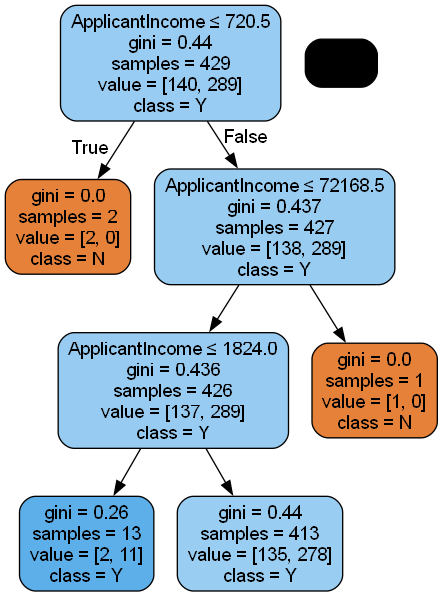

In [17]:
#features = x_cat.columns
features = ['ApplicantIncome']

dot_data = StringIO()
export_graphviz(clf, out_file=dot_data,  
                filled=True, rounded=True,
                special_characters=True, feature_names = features ,class_names=['N','Y'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png("loan_tree.png")
Image(graph.create_png())

## predict

In [24]:
x_test.drop(columns=cat_df.columns, axis=1, inplace=True)
x_test = pd.concat([x_test, x_test_cat], axis=1)
x_test.shape

(185, 14)

In [27]:
y_pred = clf.predict(x_test[["ApplicantIncome"]])
print("Predicted Results:\n", y_pred)


Predicted Results:
 ['Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y']


In [35]:
pd.DataFrame(y_pred).value_counts()

0
Y    182
N      3
Name: count, dtype: int64

In [29]:
predictions = clf.predict_proba(x_test[["ApplicantIncome"]])
predictions

AttributeError: 'numpy.ndarray' object has no attribute 'head'

In [30]:

recall_score(y_test,y_pred, average='macro') #weighted, micro, binary
print ("Test Accuracy Score : ", accuracy_score(y_test,y_pred)*100) 
print("Test Confusion Matrix :\n", confusion_matrix(y_test, y_pred))
print("Test Classification Report :\n", classification_report(y_test, y_pred))

Test Accuracy Score :  70.27027027027027
Test Confusion Matrix :
 [[  0  52]
 [  3 130]]
Test Classification Report :
               precision    recall  f1-score   support

           N       0.00      0.00      0.00        52
           Y       0.71      0.98      0.83       133

    accuracy                           0.70       185
   macro avg       0.36      0.49      0.41       185
weighted avg       0.51      0.70      0.59       185



In [ ]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.hist(predictions[:,0], bins=50, label="No" , alpha=0.5)
ax.hist(predictions[:,1], bins=50, label="Yes", color='r', alpha =0.5)
ax.legend()

[Text(0.5, 0.875, 'x[1] <= 0.5\ngini = 0.44\nsamples = 429\nvalue = [140, 289]'),
 Text(0.25, 0.625, 'x[0] <= 240.0\ngini = 0.17\nsamples = 64\nvalue = [58, 6]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[9] <= 0.5\ngini = 0.408\nsamples = 7\nvalue = [5, 2]'),
 Text(0.0625, 0.125, 'gini = 0.278\nsamples = 6\nvalue = [5, 1]'),
 Text(0.1875, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.375, 0.375, 'x[2] <= 0.5\ngini = 0.131\nsamples = 57\nvalue = [53, 4]'),
 Text(0.3125, 0.125, 'gini = 0.0\nsamples = 11\nvalue = [11, 0]'),
 Text(0.4375, 0.125, 'gini = 0.159\nsamples = 46\nvalue = [42, 4]'),
 Text(0.75, 0.625, 'x[3] <= 0.5\ngini = 0.348\nsamples = 365\nvalue = [82, 283]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[0] <= 420.0\ngini = 0.432\nsamples = 117\nvalue = [37, 80]'),
 Text(0.5625, 0.125, 'gini = 0.414\nsamples = 113\nvalue = [33, 80]'),
 Text(0.6875, 0.125, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.875, 0.375, 'x[9] <= 0.5\ngini = 0.2

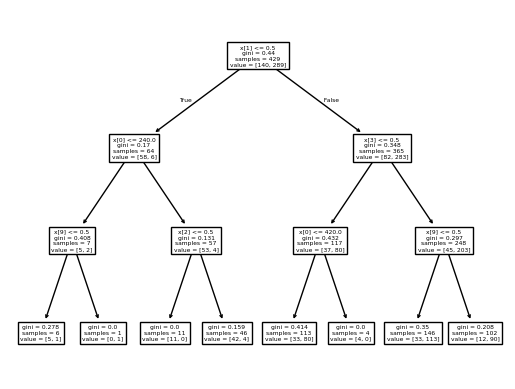

In [36]:
from sklearn import tree 
tree.plot_tree(clf.fit(x_cat, y_train)) 

In [ ]:
from sklearn.tree.export import export_text
text = export_text(clf, feature_names=x_cat.columns)

In [ ]:
import seaborn as sns
cnf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(cnf_matrix, annot=True)

## post pruning

{'ccp_alphas': array([0.00000000e+00, 2.37904934e-18, 3.56857401e-18, 3.56857401e-18,
       3.56857401e-18, 4.22576238e-18, 4.75809868e-18, 4.75809868e-18,
       6.33864357e-18, 8.64360486e-18, 9.98816562e-18, 1.09485662e-17,
       1.69030495e-17, 2.49800181e-17, 1.48957299e-03, 1.54320988e-03,
       1.54320988e-03, 1.57728707e-03, 1.57728707e-03, 1.60085379e-03,
       1.61812298e-03, 1.69515978e-03, 1.75746924e-03, 2.14899713e-03,
       2.16785382e-03, 2.26389672e-03, 2.33100233e-03, 2.33100233e-03,
       2.33100233e-03, 2.36394936e-03, 2.48461089e-03, 2.65565990e-03,
       2.75658438e-03, 2.78551532e-03, 2.78551532e-03, 2.97914598e-03,
       2.98862299e-03, 3.11249444e-03, 3.15457413e-03, 3.18515212e-03,
       3.22683127e-03, 3.24746038e-03, 3.46311260e-03, 3.77684054e-03,
       3.95290766e-03, 4.01386101e-03, 4.03842442e-03, 4.15620092e-03,
       4.20274457e-03, 4.20462509e-03, 4.22166479e-03, 4.50378302e-03,
       4.59432668e-03, 5.09333708e-03, 5.23174877e-03, 5.83182

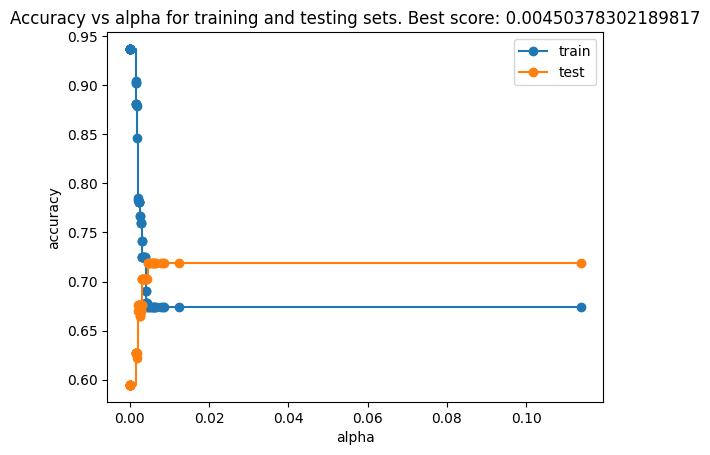

In [112]:
'''
DecisionTreeClassifier.cost_complexity_pruning_path returns the effective alphas and the corresponding total leaf impurities at each step of the 
pruning process. As alpha increases, more of the tree is pruned, which increases the total impurity of its leaves.
'''
ccp_path = clf.cost_complexity_pruning_path(x_train, y_train)
ccp_alphas = ccp_path.ccp_alphas
impurities = ccp_path.impurities
print(ccp_path)


X = x_train[["ApplicantIncome"]]
X_t = x_test[["ApplicantIncome"]]
train_scores=[]
test_scores= []
trees = []
for ccp_alpha in ccp_alphas:
    clf=DecisionTreeClassifier(random_state=0,ccp_alpha=ccp_alpha)
    clf.fit(X,y_train)
    trees.append(clf)
    train_scores.append(clf.score(X, y_train))
    test_scores.append(clf.score(X_t, y_test))

best_alpha = ccp_alphas[np.argmax(test_scores)]
best_alpha

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title(f"Accuracy vs alpha for training and testing sets. Best score: {best_alpha}")
ax.plot(ccp_alphas, train_scores, marker='o', label="train",drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker='o', label="test",drawstyle="steps-post")
ax.legend()
plt.show()

In [113]:
best_tree=DecisionTreeClassifier(random_state=0,ccp_alpha=best_alpha)
best_tree.fit(X,y_train)
print(best_tree.score(X, y_train))
best_tree.score(X_t, y_test)

0.6736596736596736


0.7189189189189189

In [114]:
result = pd.DataFrame(data=
             { 
    "ccp_alphas": ccp_path["ccp_alphas"],
    "impurities": ccp_path["impurities"],
    "train_scores": train_scores,
    "test_scores": test_scores
   })

result.iloc[np.argmax(result["test_scores"]), :]

ccp_alphas      0.004504
impurities      0.194764
train_scores    0.673660
test_scores     0.718919
Name: 51, dtype: float64

[Text(0.5, 0.5, 'gini = 0.44\nsamples = 429\nvalue = [140, 289]')]

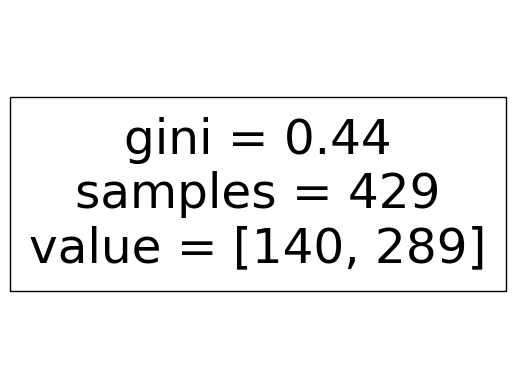

In [115]:
tree.plot_tree(best_tree) 

In [95]:
best_tree.feature_importances_

array([0.])

In [89]:
print(best_tree.get_depth())
print(best_tree.get_n_leaves())

0
1


In [91]:
y_pred_pruned = best_tree.predict(x_test[["ApplicantIncome"]])
print("Predicted Results:\n", y_pred_pruned)
recall_score(y_test,y_pred_pruned, average='macro') #weighted, micro, binary
print ("Test Accuracy Score : ", accuracy_score(y_test,y_pred_pruned)*100) 
print("Test Confusion Matrix :\n", confusion_matrix(y_test, y_pred_pruned))
print("Test Classification Report :\n", classification_report(y_test, y_pred_pruned))

Predicted Results:
 ['Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y']
Test Accuracy Score :  71.89189189189189
Test Confusion Matrix :
 [[  0  52]
 [  0 133]]
Test Classification Report :
               precision    recall  f1-score   support

           N       0.00      0.00      0.00        52


C:\Users\nedwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\nedwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\nedwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

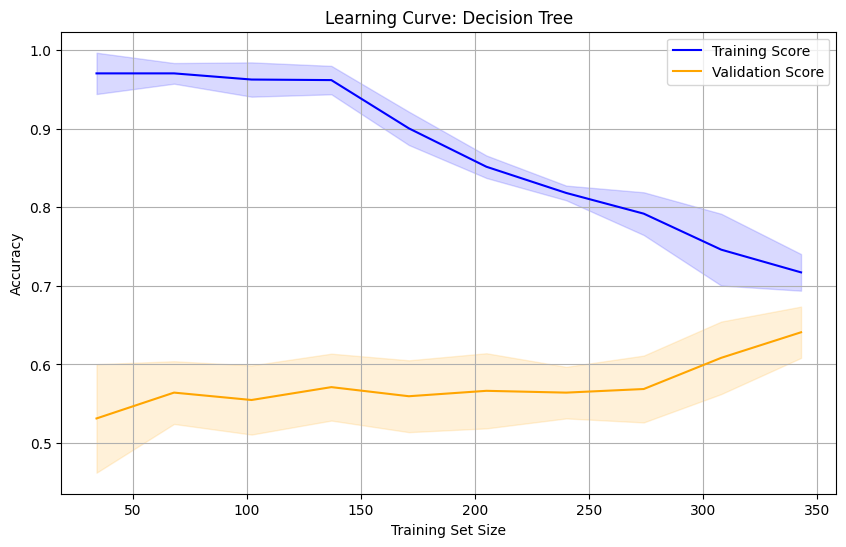

In [98]:
from sklearn.model_selection import learning_curve
# model
model = DecisionTreeClassifier(random_state=42,ccp_alpha=best_alpha)

# learning curve
train_sizes, train_scores, test_scores = learning_curve(
    estimator=model,
    X=X,                 # your features
    y=y_train,                 # your target
    cv=5,                # number of folds
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy',
    shuffle=True,
    random_state=42
)

# mean and std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# plot
plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_mean, label='Training Score', color='blue')
plt.plot(train_sizes, test_mean, label='Validation Score', color='orange')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                 color='blue', alpha=0.15)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std,
                 color='orange', alpha=0.15)

plt.title('Learning Curve: Decision Tree')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [99]:
# Create a mesh grid for plotting
x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
y_min, y_max = y.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Predict over the grid
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, cmap='Pastel2', alpha=0.7)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision Tree Decision Boundary")
plt.show()

InvalidIndexError: (slice(None, None, None), 0)

# Tree

In [29]:
tree = DecisionTreeClassifier(criterion='gini', max_depth=3, splitter='best', random_state=42)
tree.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


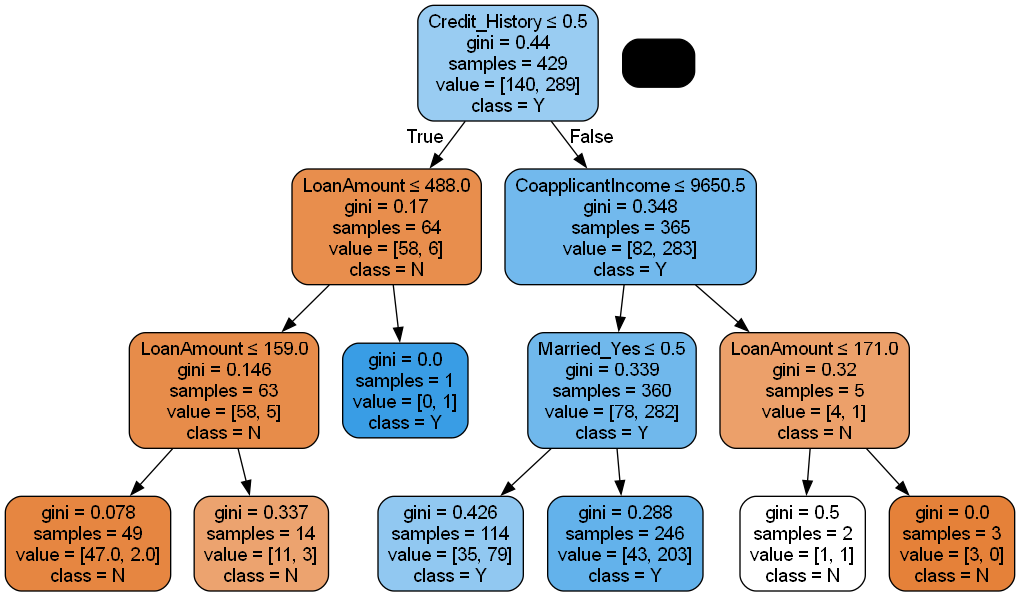

In [30]:
dot_data = StringIO()
export_graphviz(tree, out_file=dot_data,  
                filled=True, rounded=True,
                special_characters=True, feature_names = x_train.columns ,class_names=['N','Y'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png("loan_tree.png")
Image(graph.create_png())

In [31]:
# Features used 
print(tree.feature_names_in_[tree.tree_.feature[tree.tree_.feature > 0]])

# split thresholds
print(tree.tree_.threshold)



['Credit_History' 'LoanAmount' 'LoanAmount' 'CoapplicantIncome'
 'Married_Yes' 'LoanAmount']
[ 5.0000e-01  4.8800e+02  1.5900e+02 -2.0000e+00 -2.0000e+00 -2.0000e+00
  9.6505e+03  5.0000e-01 -2.0000e+00 -2.0000e+00  1.7100e+02 -2.0000e+00
 -2.0000e+00]


In [32]:
feature_index = tree.tree_.feature.tolist()
mapped = map(lambda x: "Leaf" if x==-2 else tree.feature_names_in_[x] , feature_index)
node = list(mapped)
node

['Credit_History',
 'LoanAmount',
 'LoanAmount',
 'Leaf',
 'Leaf',
 'Leaf',
 'CoapplicantIncome',
 'Married_Yes',
 'Leaf',
 'Leaf',
 'LoanAmount',
 'Leaf',
 'Leaf']

In [33]:
#prediction values at each node
df = pd.DataFrame(data=[node, tree.tree_.value[:,:,0].reshape(-1,), tree.tree_.value[:,:,1].reshape(-1,)]).T
df.rename(columns={0:"Node", 1:"Pred_N", 2:"Pred_Y"}, inplace=True)
df

,Node,Pred_N,Pred_Y
0,Credit_History,0.32634,0.67366
1,LoanAmount,0.90625,0.09375
2,LoanAmount,0.920635,0.079365
3,Leaf,0.959184,0.040816
4,Leaf,0.785714,0.214286
5,Leaf,0.0,1.0
6,CoapplicantIncome,0.224658,0.775342
7,Married_Yes,0.216667,0.783333
8,Leaf,0.307018,0.692982
9,Leaf,0.174797,0.825203


### tree calculation

In [58]:
temp = pd.concat([x_train, y_train], axis=1)
temp.shape

(429, 15)

In [59]:
temp["Credit_History"].value_counts()

Credit_History
1.0    365
0.0     64
Name: count, dtype: int64

In [61]:
temp.groupby("Credit_History")["Loan_Status"].value_counts()

Credit_History  Loan_Status
0.0             N               58
                Y                6
1.0             Y              283
                N               82
Name: count, dtype: int64

In [71]:
 (1 - (82/365)**2 - (283/365)**2)

0.34837305310564837

In [72]:
#gini impurity for credit_history < 0.5
gini = ((64/429) * (1 - (58/64)**2 - (6/64)**2)) + ((365/429) * (1 - (82/365)**2 - (283/365)**2))
print(f'gini impurity for credit_history < 0.5 = {gini}')

gini impurity for credit_history < 0.5 = 0.3217509659290481


### evaluate and predict

In [34]:
tree.feature_importances_

array([0.        , 0.0563139 , 0.04906217, 0.        , 0.84892148,
       0.        , 0.04570244, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        ])

<Axes: ylabel='None'>

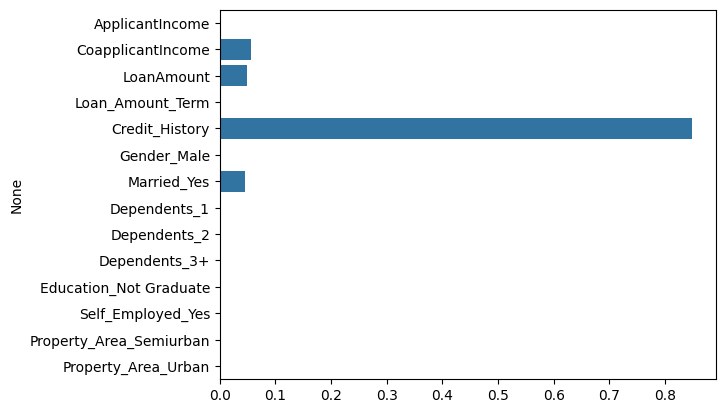

In [47]:
sns.barplot(x=tree.feature_importances_, y=x_train.columns)

In [18]:
x_test.drop(columns=cat_df.columns, axis=1, inplace=True)
x_test = pd.concat([x_test, x_test_cat], axis=1)
x_test.shape

(185, 14)

In [38]:
y_pred = tree.predict(x_test)
print("Predicted Results:\n", y_pred)

Predicted Results:
 ['Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'N' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'N' 'Y' 'N' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'N' 'N' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'N'
 'Y' 'Y' 'Y' 'Y' 'N' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y']


In [39]:
pd.DataFrame(y_pred).value_counts()

0
Y    161
N     24
Name: count, dtype: int64

In [40]:
predictions = tree.predict_proba(x_test)

In [41]:
tree.score(x_train, y_train)

0.8041958041958042

In [42]:
print ("Test Accuracy Score : ", accuracy_score(y_test,y_pred)*100) 

Test Accuracy Score :  83.78378378378379


In [43]:
precision = precision_score(y_test, y_pred, average=None)
print(f'precision: {precision}')
recall = recall_score(y_test, y_pred, average=None)
print(f'recall: {recall}')

precision: [0.95833333 0.81987578]
recall: [0.44230769 0.9924812 ]


In [44]:
print("Test Confusion Matrix :\n", confusion_matrix(y_test, y_pred))
print("Test Classification Report :\n", classification_report(y_test, y_pred))

Test Confusion Matrix :
 [[ 23  29]
 [  1 132]]
Test Classification Report :
               precision    recall  f1-score   support

           N       0.96      0.44      0.61        52
           Y       0.82      0.99      0.90       133

    accuracy                           0.84       185
   macro avg       0.89      0.72      0.75       185
weighted avg       0.86      0.84      0.82       185



### ROC & PR curves

In [45]:
#ROC-AUC
tree_roc_auc = roc_auc_score(y_test,  predictions[:,1])
print(tree_roc_auc)

0.7281665702718334


In [63]:
fpr, tpr, thresholds = roc_curve(y_test, predictions[:,1], pos_label="Y", drop_intermediate=False )
print(tpr)

[0.         0.         0.60902256 0.9924812  0.9924812  1.        ]


Best threshold: 0.6929824561403509


Text(0, 0.5, 'TPR - Correctly predicted +ves from overall +ves')

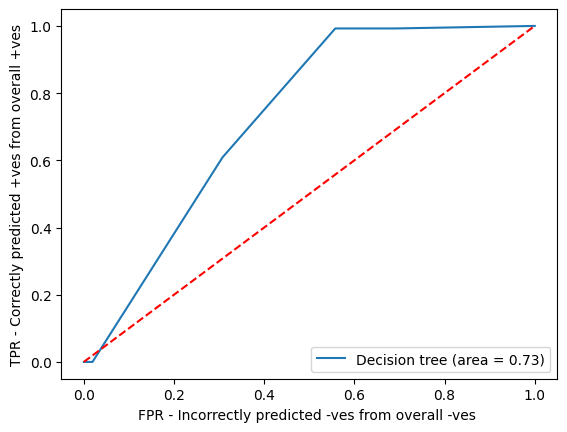

In [48]:
#Youden’s J statistic
youden_index = tpr - fpr  
best_threshold = thresholds[youden_index.argmax()] 
print(f"Best threshold: {best_threshold}")

plt.figure()
plt.plot(fpr, tpr, label='Decision tree (area = %0.2f)' % tree_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.legend(loc="lower right")
plt.xlabel("FPR - Incorrectly predicted -ves from overall -ves ")
plt.ylabel("TPR - Correctly predicted +ves from overall +ves")   

In [64]:
thres = best_threshold
y_pred_final = (predictions[:,1] >= thres).astype(int)
y_pred_final = pd.Series(y_pred_final).map({1: "Y", 0: 'N'})  
print('Evaluate the new predictions on best threshold:')
print(classification_report(y_test, y_pred_final))
print(y_pred_final.value_counts())
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()
print(confusion_matrix(y_test, y_pred_final))
tpr_thres = tp/(tp+fn)
print(f'tpr at threshold {thres}: {tpr_thres}')
fpr_thres = fp/(tn+fp)
print(f'fpr at threshold {thres}: {fpr_thres}')

Evaluate the new predictions on best threshold:
              precision    recall  f1-score   support

           N       0.96      0.44      0.61        52
           Y       0.82      0.99      0.90       133

    accuracy                           0.84       185
   macro avg       0.89      0.72      0.75       185
weighted avg       0.86      0.84      0.82       185

Y    161
N     24
Name: count, dtype: int64
[[ 23  29]
 [  1 132]]
tpr at threshold 0.6929824561403509: 0.9924812030075187
fpr at threshold 0.6929824561403509: 0.5576923076923077


* The area under the curve is 0.73 which is at a moderate to good scale. Since a random classifier has an ROC AUC of 0.5, an AUC of 0.73 indicates meaningful improvement over random guessing.
* At highest threshold both the FPR and TPR are around 0. 
* As the threshold decrease both gradually increase
* The optimal threshold based on Youden's J is 0.69
    * At the best threshold, TPR is 0.99, meaning we captured 99% of the true positives correctly
    * At the best threshold, FPR is 0.55, meaning 55% of negative cases are incorrectly classified as positive, indicating a high false-positive rate.
* Need to be cautious and adjust the threshold based on business requirement as FP is higher. If our requirement is to catch all TPs then we can live with this amount of FPs
* So, the model does a pretty decent job in separating the positives and negatives based on ROC

In [88]:
roc_df = pd.DataFrame([tpr, fpr, thresholds]).T
roc_df.rename(columns={0:"tpr", 1:"fpr", 2:"threshold"}, inplace=True)
roc_df[roc_df["threshold"] == thres]

,tpr,fpr,threshold
3,0.992481,0.557692,0.692982


In [65]:
pd.DataFrame(y_pred_final).value_counts()

0
Y    161
N     24
Name: count, dtype: int64

In [59]:
y_pred_thres = (predictions[:,1] >= 0.80).astype(int)
pd.DataFrame(y_pred_thres).value_counts()

0
1    97
0    88
Name: count, dtype: int64

Decision Tree: PR AUC=0.577
Best PR threshold: 0.6929824561403509
Best F1: 0.8979591831780045
Precision: 0.8198757763975155
Recall: 0.9924812030075187
Average precision score: 0.83


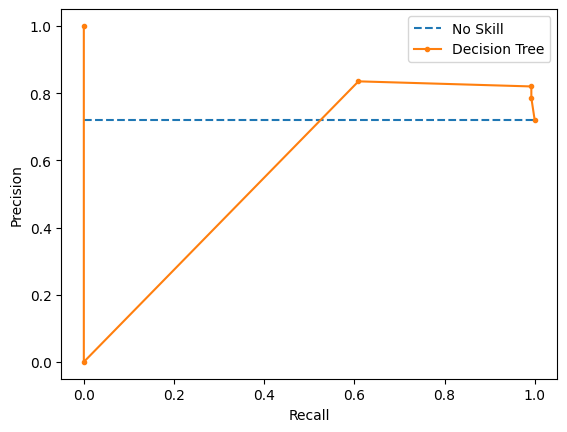

In [548]:
#PR curve
lr_f1= f1_score(y_test, y_pred, pos_label="Y")
lr_precision, lr_recall, lr_thresholds = precision_recall_curve(y_test, predictions[:,1], pos_label="Y")
lr_auc = auc(lr_recall, lr_precision)
print('Decision Tree: PR AUC=%.3f' % (lr_auc))

# precision, recall, thresholds from precision_recall_curve
f1_scores = 2 * (lr_precision[:-1] * lr_recall[:-1]) / (
    lr_precision[:-1] + lr_recall[:-1] + 1e-9
)

best_idx = np.argmax(f1_scores)
best_pr_threshold = lr_thresholds[best_idx]

print("Best PR threshold:", best_pr_threshold)
print("Best F1:", f1_scores[best_idx])
print("Precision:", lr_precision[best_idx])
print("Recall:", lr_recall[best_idx])

no_skill = len(y_test[y_test == 'Y']) / len(y_test)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--', label='No Skill')
plt.plot(lr_recall, lr_precision, marker='.', label='Decision Tree')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()

avg_precision = average_precision_score(y_test, predictions[:,1], pos_label="Y")
print('Average precision score: {0:0.2f}'.format(avg_precision))

* No skill at 0.71 means that the positive class is dominating the dataset and A classifier must achieve precision above 0.71 to outperform random guessing.
* Once precision reaches ~0.8, recall can be pushed very high with little additional precision loss.
* Average precision is higher. 
* Optimal threshold is 0.69
* We select a threshold yielding ~0.99 recall while maintaining ~0.8 precision, if false negatives are more costly than false positives in this application.

### Gain & Lift charts

In [565]:
# Calculate gains
y_test_mapped = y_test.map({'Y': 1, 'N': 0})  
gain_df = pd.DataFrame({'true': y_test_mapped, 'pred': predictions[:,1]})
gain_df = gain_df.sort_values('pred', ascending=False)
gain_df['cumulative_actual_class'] = np.cumsum(gain_df['true'])
gain_df['cumulative'] = np.cumsum(gain_df['true']) / gain_df['true'].sum()
gain_df['percentage'] = np.arange(start=1, stop=len(gain_df) + 1) / len(gain_df)
gain_df['lift'] = gain_df['cumulative'] / gain_df['percentage']   #lift
gain_df

,true,pred,cumulative_actual_class,cumulative,percentage,lift
177,0,1.000000,0,0.000000,0.005405,0.000000
372,1,0.825203,1,0.007519,0.010811,0.695489
503,0,0.825203,1,0.007519,0.016216,0.463659
388,1,0.825203,2,0.015038,0.021622,0.695489
593,1,0.825203,3,0.022556,0.027027,0.834586
...,...,...,...,...,...,...
613,0,0.040816,132,0.992481,0.978378,1.014414
548,0,0.040816,132,0.992481,0.983784,1.008841
122,1,0.040816,133,1.000000,0.989189,1.010929
584,0,0.040816,133,1.000000,0.994595,1.005435


In [582]:
gain_df.head(50)

,true,pred,cumulative_actual_class,cumulative,percentage,lift
177,0,1.000000,0,0.000000,0.005405,0.000000
372,1,0.825203,1,0.007519,0.010811,0.695489
503,0,0.825203,1,0.007519,0.016216,0.463659
388,1,0.825203,2,0.015038,0.021622,0.695489
593,1,0.825203,3,0.022556,0.027027,0.834586
574,0,0.825203,3,0.022556,0.032432,0.695489
224,1,0.825203,4,0.030075,0.037838,0.794844
276,1,0.825203,5,0.037594,0.043243,0.869361
362,1,0.825203,6,0.045113,0.048649,0.927318
583,0,0.825203,6,0.045113,0.054054,0.834586


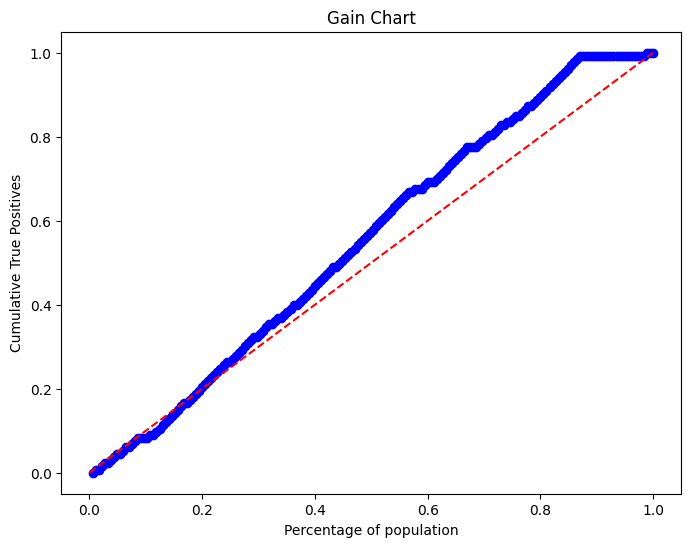

In [567]:
# Plotting the gain chart
plt.figure(figsize=(8, 6))
plt.plot(gain_df['percentage'], gain_df['cumulative'], marker='o', linestyle='-', color='b')
plt.plot([0, 1], [0, 1], color='r', linestyle='--')
plt.title('Gain Chart')
plt.xlabel('Percentage of population')
plt.ylabel('Cumulative True Positives')
plt.show()

* The model’s ranking ability is only marginally better than random. Model is not doing better in predicting postivies as positives. The model does not effectively concentrate positives in the top-ranked population.
* We capture 99% of True positives only when the population is around 87%. Poor lift in early segments.
    * Top 20% → captures ~22–25% positives
    * Top 50% → captures ~50–55% positives

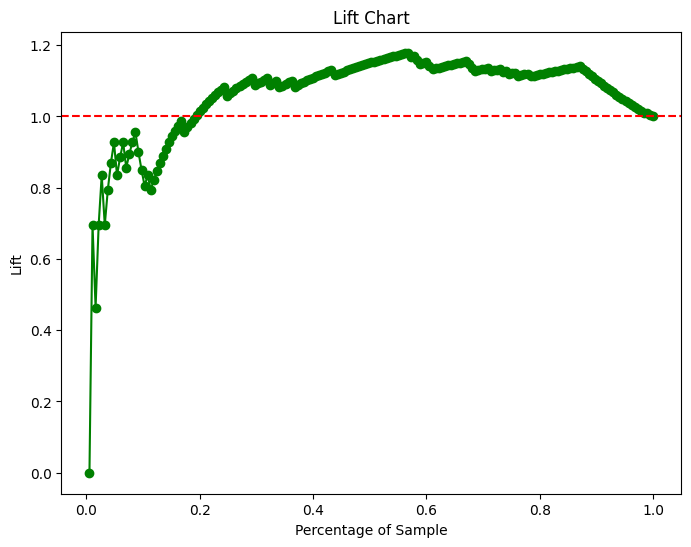

In [570]:
# Plotting the lift chart
plt.figure(figsize=(8, 6))
plt.plot(gain_df['percentage'], gain_df['lift'], marker='o', linestyle='-', color='g')
plt.axhline(y=1, color='r', linestyle='--')
plt.title('Lift Chart')
plt.xlabel('Percentage of Sample')
plt.ylabel('Lift')
plt.show()

* Gain at 20% ≈ 21%
* Lift = 21 / 20 = 1.05
* Model is Only 1.05× better than random → weak

### Learning curve

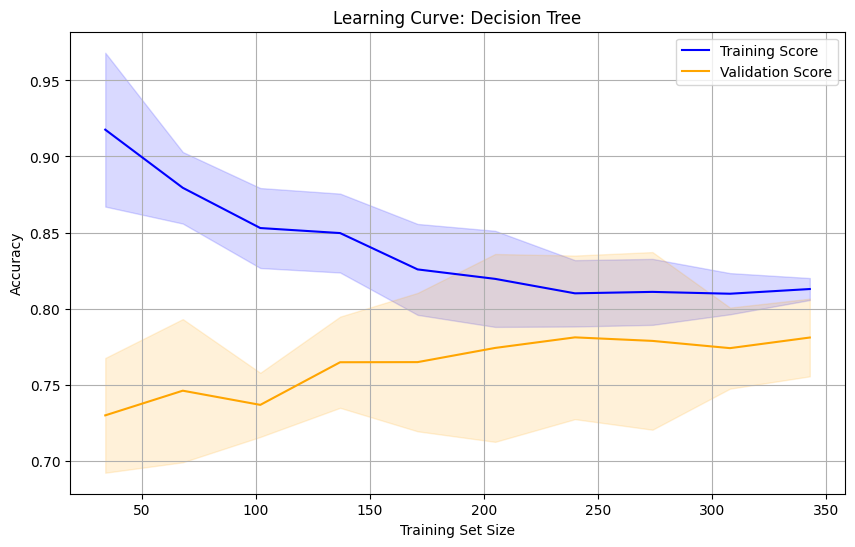

In [74]:
from sklearn.model_selection import learning_curve

# learning curve
train_sizes, train_scores, test_scores = learning_curve(
    estimator=tree,
    X=x_train,                 # your features
    y=y_train,                 # your target
    cv=5,                # number of folds
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy',
    shuffle=True,
    random_state=42
)

# mean and std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# plot
plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_mean, label='Training Score', color='blue')
plt.plot(train_sizes, test_mean, label='Validation Score', color='orange')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                 color='blue', alpha=0.15)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std,
                 color='orange', alpha=0.15)

plt.title('Learning Curve: Decision Tree')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

### Decision path

In [360]:
print(x_test.iloc[0,:]) # sample 1 row
row1 = np.asarray(x_test.iloc[0,:]).reshape(1,-1)


ApplicantIncome             2346
CoapplicantIncome           1600
LoanAmount                 132.0
Loan_Amount_Term           360.0
Credit_History               1.0
Gender_Male                 True
Married_Yes                False
Dependents_1               False
Dependents_2               False
Dependents_3+              False
Education_Not Graduate      True
Self_Employed_Yes          False
Property_Area_Semiurban     True
Property_Area_Urban        False
Name: 386, dtype: object
[[1 0 0 0 0 0 1 1 1 0 0 0 0]]
[0 6 7 8]


In [363]:
path = tree.decision_path(row1)
print(path.toarray())

# Get indices of visited nodes
visited_nodes = path.indices
print(visited_nodes)


[[1 0 0 0 0 0 1 1 1 0 0 0 0]]
[0 6 7 8]


In [371]:
feature_names = x_test.columns  # if X is a DataFrame
t = tree.tree_
x = x_test.iloc[0]

for node_id in visited_nodes:
    feature = t.feature[node_id]
    threshold = t.threshold[node_id]

    if feature != -2:  # not a leaf
        feature_name = feature_names[feature]
        value = x.iloc[feature]
        direction = "left" if value <= threshold else "right"
        print(
            f"Node {node_id}: "
            f"{feature_name} <= {threshold:.3f}"
            f" → {direction}"
        )
    else:
        print(f"Node {node_id}: leaf node")


Node 0: Credit_History <= 0.500 → right
Node 6: CoapplicantIncome <= 9650.500 → left
Node 7: Married_Yes <= 0.500 → left
Node 8: leaf node


### PDP

In [233]:
from sklearn.inspection import partial_dependence,PartialDependenceDisplay

pdp = partial_dependence(
                    tree,       
                    features=["LoanAmount"], # column numbers of plots we want to show
                    X=x_train,            # raw predictors data.
                    feature_names=tree.feature_names_in_, # labels on graphs
                    grid_resolution=10)

pdp

{'grid_values': [array([ 55.86,  80.38, 104.9 , 129.42, 153.94, 178.46, 202.98, 227.5 ,
         252.02, 276.54])],
 'average': array([[0.66925931, 0.66925931, 0.66925931, 0.66925931, 0.66925931,
         0.68931069, 0.68931069, 0.68931069, 0.68931069, 0.68931069]])}

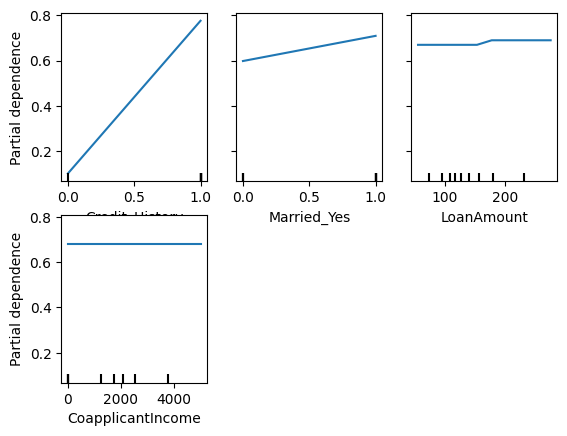

In [235]:
from sklearn.inspection import partial_dependence,PartialDependenceDisplay

deciles = {"Credit_History": np.linspace(0, 1, num=5)}

PartialDependenceDisplay.from_estimator(
    estimator=tree,
    X=x_train,
    features=["Credit_History", "Married_Yes", "LoanAmount", "CoapplicantIncome"],
    feature_names=tree.feature_names_in_,
    target=1,
    response_method='predict_proba',
    #deciles=deciles,
    grid_resolution=10
)


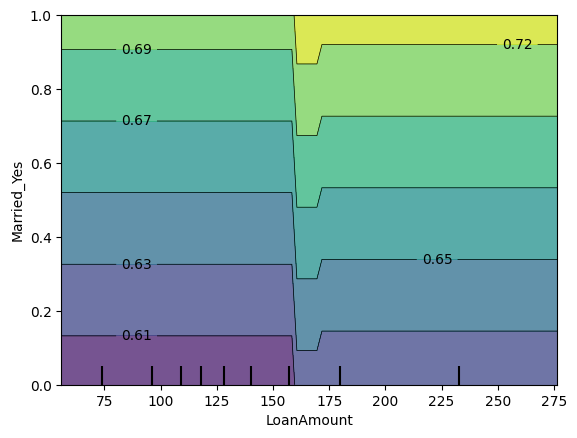

In [268]:
PartialDependenceDisplay.from_estimator(
    tree,
    x_train,
    features=[( "LoanAmount", "Married_Yes")],
    feature_names=tree.feature_names_in_,
    target=1,/````w 
)


### Permutation Importance

In [307]:
#Permutation Importance
from sklearn.inspection import permutation_importance
result = permutation_importance(tree, x_test, y_test, scoring='accuracy', n_repeats=5, random_state=42)

importance = pd.DataFrame(
    {"importance_mean": result["importances_mean"],
     "importance_std": result["importances_std"]},
    index=tree.feature_names_in_).sort_values(by="importance_mean", ascending=False)

importance.head()

,importance_mean,importance_std
Credit_History,0.163243,0.029089
CoapplicantIncome,0.004324,0.002162
ApplicantIncome,0.000000,0.000000
Loan_Amount_Term,0.000000,0.000000
Gender_Male,0.000000,0.000000


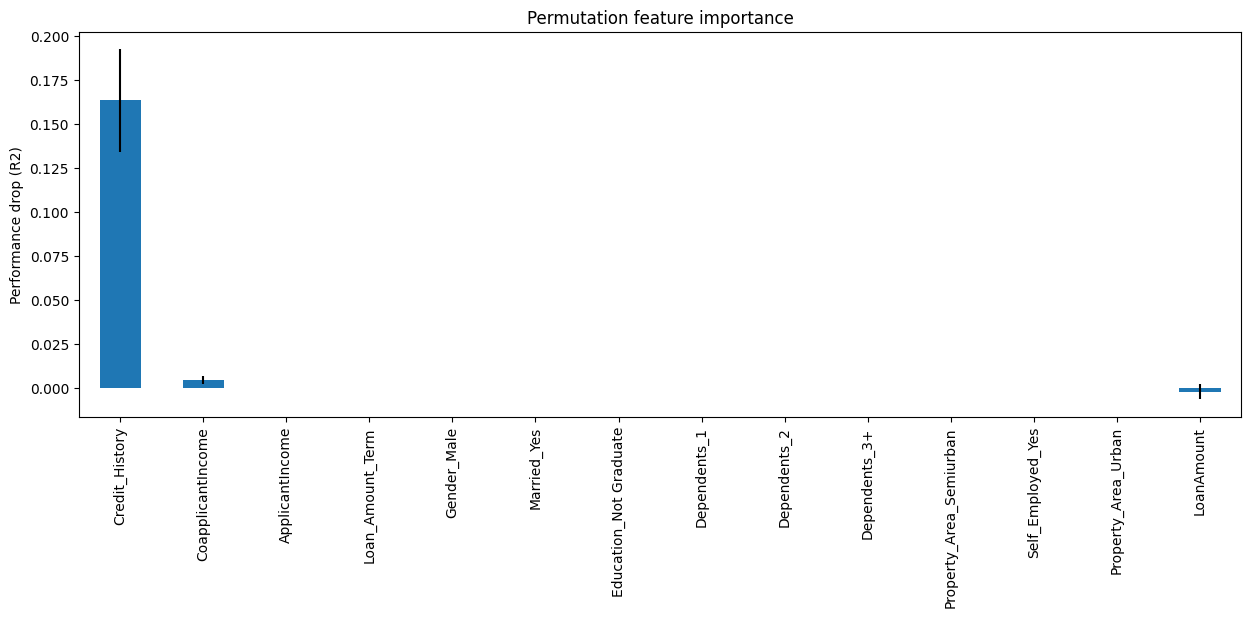

In [309]:
importance["importance_mean"].plot(figsize=(15, 5), kind="bar", yerr=importance["importance_std"])
plt.title("Permutation feature importance")
plt.ylabel("Performance drop (R2)")
plt.show()

In [298]:
#Permutation importance - Manual approach

baseline_accuracy = accuracy_score(y_test,y_pred)
importances = []
permuted_features = []
permuted_accuracy = []

for feature in x_test.columns:
    X_test_permuted = x_test.copy()
    X_test_permuted[feature] = np.random.permutation(
        X_test_permuted[feature].values
    )
    
    y_pred_perm = tree.predict(X_test_permuted)
    permuted_acc = accuracy_score(y_test, y_pred_perm) 
    #print("Accuracy after permutation:", permuted_acc)

    importances.append(baseline_accuracy - permuted_acc)  #decrease in model's performance
    permuted_features.append(feature)
    permuted_accuracy.append(permuted_acc)

# Create importance dataframe
importance_df = pd.DataFrame({
    "feature": permuted_features,
    "baseline_accuracy": baseline_accuracy,
    "permuted_accuracy": permuted_accuracy, 
    "permutation_importance": importances
}).sort_values(by="permutation_importance", ascending=False)

importance_df.head()


#Shuffling Credit_History caused a 15.1% drop in accuracy
#The model relies heavily on this feature
#Higher drop → higher importance

,feature,baseline_accuracy,permuted_accuracy,permutation_importance
4,Credit_History,0.837838,0.686486,0.151351
1,CoapplicantIncome,0.837838,0.832432,0.005405
0,ApplicantIncome,0.837838,0.837838,0.000000
3,Loan_Amount_Term,0.837838,0.837838,0.000000
5,Gender_Male,0.837838,0.837838,0.000000


# Random Forest

In [381]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=50, max_features='sqrt', max_depth=3, criterion='gini', oob_score=True, random_state=42) #max_features=none,log2,auto
rf.fit(x_train, y_train)
pred_rf = rf.predict(x_test)
print("RF Training score: ", rf.score(x_train, y_train))
print("RF OOB score: ", rf.oob_score_)
print("RF Accuracy score: ", accuracy_score(y_test, pred_rf))

RF Training score:  0.7995337995337995
RF OOB score:  0.7948717948717948
RF Accuracy score:  0.8432432432432433


Text(0.5, 1.0, 'Sorted Feature Importances')

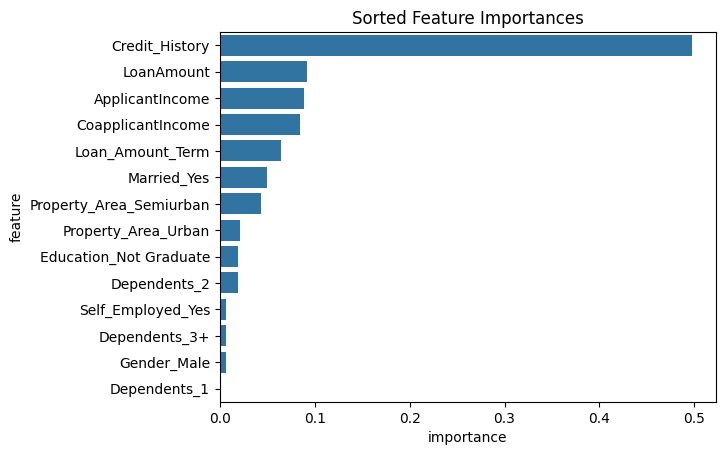

In [382]:
df_feature_importance = pd.DataFrame({
    'feature': x_train.columns,
    'importance': rf.feature_importances_
})

# Sort the DataFrame by importance in descending order
df_sorted = df_feature_importance.sort_values(by='importance', ascending=False)
sns.barplot(
    x='importance', 
    y='feature', 
    data=df_sorted, 
    order=df_sorted['feature'] # Use the sorted feature names
)
plt.title('Sorted Feature Importances')

# GBM

### gbm with validation based early stopping

In [145]:
gbm = GradientBoostingClassifier(max_depth=3, learning_rate=0.05, n_estimators=100, subsample=0.9,
                                n_iter_no_change=10, validation_fraction=0.2
                                ,verbose=2, random_state=42)
gbm.fit(x_train,y_train)

      Iter       Train Loss      OOB Improve   Remaining Time 
         1           1.2190           0.0217            0.31s
         2           1.1998           0.1307            0.27s
         3           1.1784           0.0810            0.25s
         4           1.1443          -0.0561            0.24s
         5           1.1224           0.0259            0.24s
         6           1.1396           0.3337            0.24s
         7           1.0868          -0.2788            0.25s
         8           1.0597          -0.0631            0.26s
         9           1.0470           0.0307            0.26s
        10           1.0330           0.0188            0.25s
        11           1.0055          -0.1049            0.27s
        12           1.0116           0.1729            0.28s
        13           1.0151           0.1561            0.28s
        14           1.0082           0.0562            0.29s
        15           0.9771          -0.1607            0.30s
       

,loss,'log_loss'
,learning_rate,0.05
,n_estimators,100
,subsample,0.9
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [146]:
print(gbm.n_estimators_) #actual number of trees used
print(gbm.n_trees_per_iteration_)
print(gbm.n_classes_)  #binary classification
print(gbm.n_features_in_) 
print(gbm.init_)
print(gbm.oob_score_)
#print(gbm.estimators_)

33
1
2
14
DummyClassifier()
0.8352646747591738


In [118]:
gbm.train_score_

array([1.24159049, 1.21127573, 1.18001753, 1.15179347, 1.12822899,
       1.12855371, 1.10368285, 1.09433007, 1.06683846, 1.07525193,
       1.05157302, 1.02006937, 1.03363721, 1.03239458, 0.99196018,
       0.99147132, 0.98179486, 0.96287004, 0.93912858, 0.95025931,
       0.94619255, 0.95063114, 0.94748792, 0.90757943, 0.9224289 ,
       0.91202296, 0.91286293, 0.88277382, 0.92532995, 0.90180391,
       0.92399419, 0.87790117, 0.89655336, 0.87652176])

In [119]:
gbm.oob_scores_

array([1.14854865, 1.15910277, 1.19015212, 1.20364889, 1.19505801,
       1.00499169, 1.06221018, 1.00846821, 1.11053815, 0.90431334,
       0.99581223, 1.14925741, 0.91557544, 0.82237561, 1.06961382,
       0.98711224, 0.97550077, 1.07433504, 1.19105194, 1.00391914,
       0.98447336, 0.87740744, 0.82898288, 1.12014666, 0.9225708 ,
       0.94677069, 0.89510468, 1.11467863, 0.67900389, 0.83953052,
       0.58889934, 0.95220019, 0.72254185, 0.83879966])

In [112]:
gbm.oob_improvement_ 

array([ 0.01324987, -0.01055412, -0.03104935, -0.01349678,  0.00859088,
        0.19006632, -0.05721849,  0.05374197, -0.10206994,  0.20622481,
       -0.0914989 , -0.15344517,  0.23368196,  0.09319983, -0.24723821,
        0.08250158,  0.01161147, -0.09883427, -0.1167169 ,  0.18713281,
        0.01944577,  0.10706592,  0.04842456, -0.29116378,  0.19757586,
       -0.02419989,  0.05166601, -0.21957395,  0.43567474, -0.16052663,
        0.25063118, -0.36330085,  0.22965834, -0.11625781])

In [109]:
gbm_pred = gbm.predict(x_test)

In [121]:
accuracy_score(y_test, gbm_pred)

0.8162162162162162

### gbm validation curve  

In [157]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    x_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

gbm2 = GradientBoostingClassifier(
    max_depth=3,
    learning_rate=0.05,
    n_estimators=100,
    subsample=0.9,
    verbose=1,
    #n_iter_no_change=10,
    random_state=42
)

gbm2.fit(X_tr, y_tr)

      Iter       Train Loss      OOB Improve   Remaining Time 
         1           1.2190           0.0217            0.32s
         2           1.1998           0.1307            0.31s
         3           1.1784           0.0810            0.30s
         4           1.1443          -0.0561            0.31s
         5           1.1224           0.0259            0.29s
         6           1.1396           0.3337            0.28s
         7           1.0868          -0.2788            0.27s
         8           1.0597          -0.0631            0.26s
         9           1.0470           0.0307            0.26s
        10           1.0330           0.0188            0.25s
        20           0.9303           0.1639            0.34s
        30           0.8513          -0.0226            0.27s
        40           0.7731          -0.2363            0.23s
        50           0.7768          -0.1429            0.18s
        60           0.7220          -0.1687            0.15s
       

,loss,'log_loss'
,learning_rate,0.05
,n_estimators,100
,subsample,0.9
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


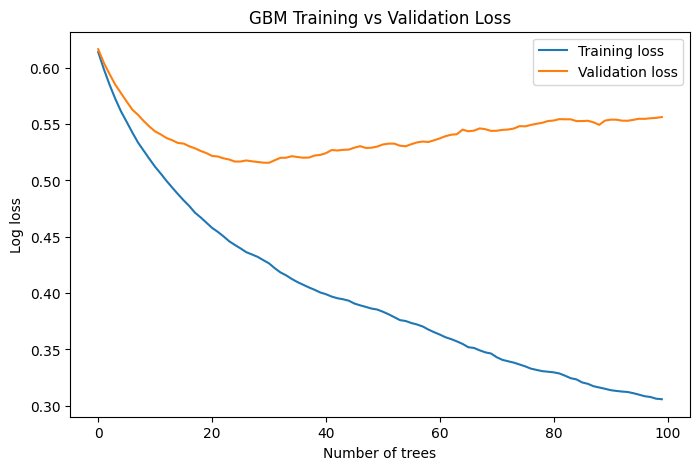

In [158]:
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt

train_losses = []
val_losses = []

for y_tr_pred, y_val_pred in zip(
        gbm2.staged_predict_proba(X_tr),
        gbm2.staged_predict_proba(X_val)):

    train_losses.append(log_loss(y_tr, y_tr_pred))
    val_losses.append(log_loss(y_val, y_val_pred))


plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Number of trees")
plt.ylabel("Log loss")
plt.legend()
plt.title("GBM Training vs Validation Loss")
plt.show()


In [159]:
np.argmin(val_losses)

np.int64(30)

In [163]:
train_losses[30]

0.4264075713949236

### gbm final fit based on best estimator from early stopping

In [171]:
gbm_final = GradientBoostingClassifier(
    max_depth=3,
    learning_rate=0.05,
    n_estimators=gbm.n_estimators_,
    subsample=0.9,
    verbose=2,
    random_state=42
)

gbm_final.fit(x_train, y_train)


      Iter       Train Loss      OOB Improve   Remaining Time 
         1           1.2276           0.0310            0.10s
         2           1.2208           0.2256            0.09s
         3           1.1764          -0.1396            0.09s
         4           1.1773           0.2214            0.09s
         5           1.1476          -0.0582            0.08s
         6           1.1246          -0.0220            0.08s
         7           1.1086           0.0120            0.08s
         8           1.0913           0.0044            0.07s
         9           1.0548          -0.1746            0.07s
        10           1.0595           0.1647            0.07s
        11           1.0561           0.0979            0.07s
        12           1.0278          -0.1350            0.06s
        13           1.0353           0.1796            0.06s
        14           1.0141          -0.0779            0.06s
        15           1.0174           0.1213            0.05s
       

,loss,'log_loss'
,learning_rate,0.05
,n_estimators,33
,subsample,0.9
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [168]:
print(gbm_final.oob_score_)


1.046064789632116


Text(0.5, 1.0, 'Sorted Feature Importances')

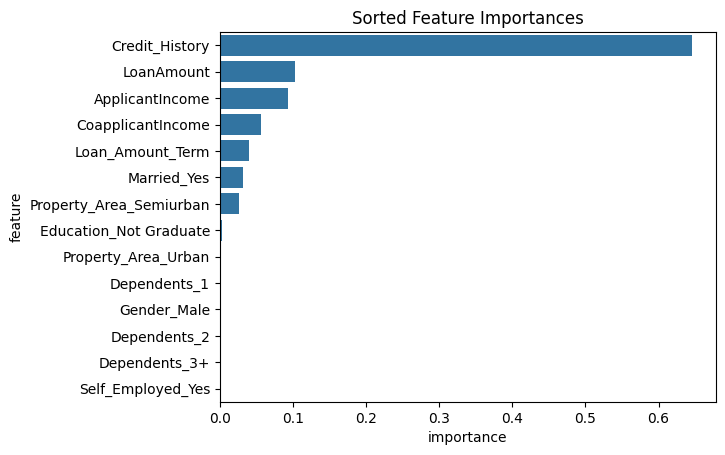

In [170]:
df_feature_importance = pd.DataFrame({
    'feature': x_train.columns,
    'importance': gbm_final.feature_importances_
})

# Sort the DataFrame by importance in descending order
df_sorted = df_feature_importance.sort_values(by='importance', ascending=False)
sns.barplot(
    x='importance', 
    y='feature', 
    data=df_sorted, 
    order=df_sorted['feature'] # Use the sorted feature names
)
plt.title('Sorted Feature Importances')

In [169]:
gbm_final_pred = gbm_final.predict(x_test)
accuracy_score(y_test, gbm_final_pred)

0.8324324324324325

In [173]:
print(classification_report(y_test, gbm_final_pred))

              precision    recall  f1-score   support

           N       0.92      0.44      0.60        52
           Y       0.82      0.98      0.89       133

    accuracy                           0.83       185
   macro avg       0.87      0.71      0.75       185
weighted avg       0.85      0.83      0.81       185



# XGBoost

In [38]:
from xgboost import XGBClassifier, XGBModel
import xgboost as xg
from sklearn.metrics import accuracy_score, mean_squared_error, roc_auc_score 

In [19]:
y_train_mapped = y_train.map(lambda x: 1 if x == 'Y' else 0)
y_test_mapped = y_test.map(lambda x: 1 if x == 'Y' else 0)

In [ ]:
XGBModel()

In [133]:
xgb = XGBClassifier(n_estimators=500, 
                    base_score=0.5,
                    early_stopping_rounds=20, 
                    learning_rate = 0.1,
                    subsample = 0.8,
                    max_depth=6,
                    tree_method = 'auto', #hist
                    max_bin = 256,
                    objective="binary:logistic",
                    eval_metric="logloss",
                    gamma=0.1,
                    reg_alpha = 1,
                    reg_lambda = 7,
                    )

xgb.fit(x_train, y_train_mapped, eval_set=[(x_train, y_train_mapped), (x_test,y_test_mapped)], verbose=True)
#dont use testing data in eval

[0]	validation_0-logloss:0.66252	validation_1-logloss:0.65986
[1]	validation_0-logloss:0.63831	validation_1-logloss:0.63329
[2]	validation_0-logloss:0.61600	validation_1-logloss:0.60913
[3]	validation_0-logloss:0.59656	validation_1-logloss:0.59065
[4]	validation_0-logloss:0.57878	validation_1-logloss:0.57473
[5]	validation_0-logloss:0.56372	validation_1-logloss:0.55757
[6]	validation_0-logloss:0.55062	validation_1-logloss:0.54452
[7]	validation_0-logloss:0.53992	validation_1-logloss:0.53391
[8]	validation_0-logloss:0.52953	validation_1-logloss:0.52442
[9]	validation_0-logloss:0.52052	validation_1-logloss:0.51620
[10]	validation_0-logloss:0.51176	validation_1-logloss:0.50801
[11]	validation_0-logloss:0.50358	validation_1-logloss:0.50196
[12]	validation_0-logloss:0.49742	validation_1-logloss:0.49730
[13]	validation_0-logloss:0.48987	validation_1-logloss:0.49319
[14]	validation_0-logloss:0.48344	validation_1-logloss:0.48835
[15]	validation_0-logloss:0.47602	validation_1-logloss:0.48487
[1

,objective,'binary:logistic'
,base_score,0.5
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,20
,enable_categorical,False
,eval_metric,'logloss'


In [134]:
print(f'Best iteration is {xgb.best_iteration} and \
   \n trainging best score is {xgb.evals_result()["validation_0"]["logloss"][xgb.best_iteration]} \
    \n validation best score is {xgb.best_score} after early stopping')

Best iteration is 39 and    
 trainging best score is 0.3872486671958214     
 validation best score is 0.4502069782163646 after early stopping


In [135]:
xgb_pred = xgb.predict(x_test)
accuracy_score(y_test_mapped, xgb_pred)

0.8324324324324325

In [55]:
xgb

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,10
,enable_categorical,False
,eval_metric,<function mea...00222FDBF7240>


In [23]:
params = {
    "objective": "binary:logistic",
    "max_depth": 3,
    "learning_rate": 0.05,
    "eval_metric": "auc"
}

dtrain =  xg.DMatrix(x_train, label=y_train_mapped)

xgb_cv = xg.cv(
    params=params,
    dtrain=dtrain,
    num_boost_round=1000,  
    nfold=5,                    # Number of folds
    stratified=True,            # Keep label distribution same in folds
    early_stopping_rounds=10,   # Stop if 'test-auc' doesn't improve
    as_pandas=True,             # Return results as a DataFrame
    seed=42
)

print(f"Best number of boosting rounds: {len(xgb_cv)}")
print(xgb_cv.tail(1)) # Shows final train/test scores and std dev

Best number of boosting rounds: 20
    train-auc-mean  train-auc-std  test-auc-mean  test-auc-std
19        0.845728       0.006041       0.740254      0.018212
